#### Third Tutorial for Brian

In [70]:
from brian2 import *
%matplotlib inline

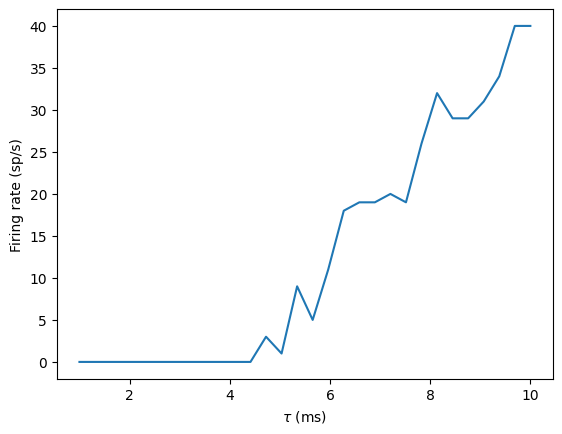

In [71]:
start_scope()

num_inputs = 100
input_rate = 10 * Hz
weight = 0.1

tau_range = np.linspace(1, 10, 30) * ms

output_rates = []

for tau in tau_range:
    p = PoissonGroup(num_inputs, rates=input_rate)
    eqs = """
    dv/dt = -v/tau : 1
    """
    g = NeuronGroup(1, eqs, threshold="v>1", reset="v=0", method="exact")
    s = Synapses(p, g, on_pre="v += weight")

    s.connect()
    spike_monitor = SpikeMonitor(g)

    run(1*second)
    output_rates.append(spike_monitor.num_spikes/second)

plt.plot(tau_range/ms, output_rates)
plt.xlabel(r"$\tau$ (ms)")
plt.ylabel("Firing rate (sp/s)");

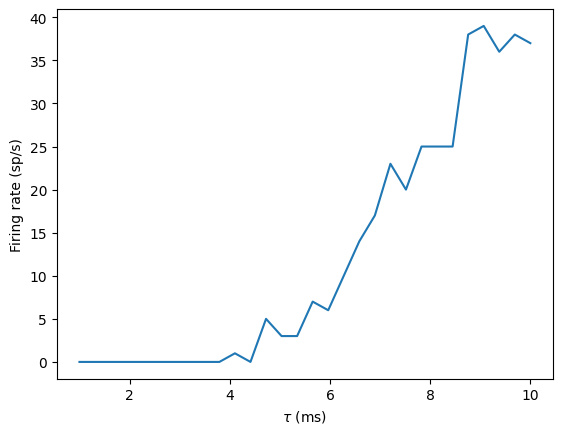

In [72]:
start_scope()

num_inputs = 100
input_rate = 10 * Hz
weight = 0.1

tau_range = np.linspace(1, 10, 30) * ms

output_rates = []

p = PoissonGroup(num_inputs, rates=input_rate)
eqs = """
dv/dt = -v/tau : 1
"""
g = NeuronGroup(1, eqs, threshold="v>1", reset="v=0", method="exact")
s = Synapses(p, g, on_pre="v += weight")

s.connect()
spike_monitor = SpikeMonitor(g)
store()
for tau in tau_range:
    restore()
    run(1*second)
    output_rates.append(spike_monitor.num_spikes/second)

plt.plot(tau_range/ms, output_rates)
plt.xlabel(r"$\tau$ (ms)")
plt.ylabel("Firing rate (sp/s)");

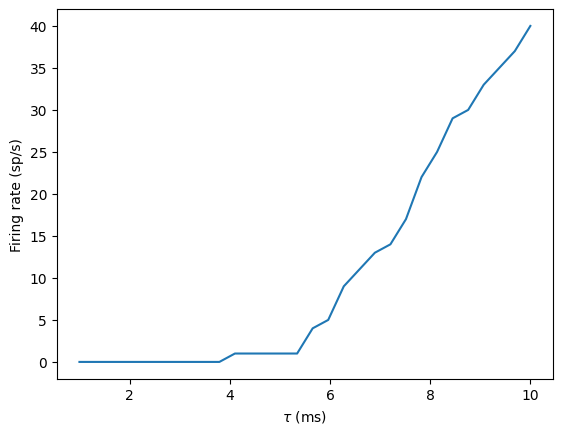

In [73]:
start_scope()

num_inputs = 100
input_rate = 10 * Hz
weight = 0.1

tau_range = np.linspace(1, 10, 30) * ms

output_rates = []

p = PoissonGroup(num_inputs, rates=input_rate)
eqs = """
dv/dt = -v/tau : 1
"""

spike_monitor = SpikeMonitor(p)
net = Network(p, spike_monitor)
net.run(1*second)
spikes_i = spike_monitor.i
spikes_t = spike_monitor.t
SGG = SpikeGeneratorGroup(num_inputs, spikes_i, spikes_t)
g = NeuronGroup(1, eqs, threshold="v>1", reset="v=0", method="exact")
s = Synapses(SGG, g, on_pre="v += weight")
s.connect()
spike_monitor = SpikeMonitor(g)
net = Network(SGG, g, s, spike_monitor)

net.store()
for tau in tau_range:
    net.restore()
    net.run(1*second)
    output_rates.append(spike_monitor.num_spikes/second)

plt.plot(tau_range/ms, output_rates)
plt.xlabel(r"$\tau$ (ms)")
plt.ylabel("Firing rate (sp/s)");

WARNING    'tau' is an internal variable of group 'neurongroup_7', but also exists in the run namespace with the value 10. * msecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


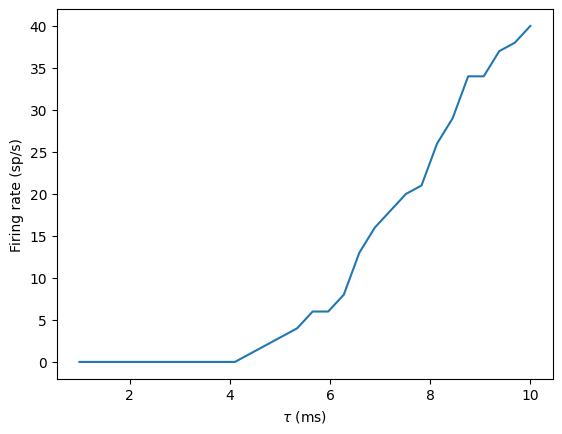

In [74]:
start_scope()

num_inputs = 100
input_rate = 10 * Hz
weight = 0.1

tau_range = np.linspace(1, 10, 30) * ms
num_tau = len(tau_range)

output_rates = []

p = PoissonGroup(num_inputs, rates=input_rate)
eqs = """
dv/dt = -v/tau : 1
tau: second
"""

g = NeuronGroup(num_tau, eqs, threshold="v>1", reset="v=0", method="exact")
g.tau = tau_range
s = Synapses(p, g, on_pre="v += weight")
s.connect()
spike_monitor = SpikeMonitor(g)
run(1 * second)

output_rates = spike_monitor.count/second

plt.plot(tau_range/ms, output_rates)
plt.xlabel(r"$\tau$ (ms)")
plt.ylabel("Firing rate (sp/s)");

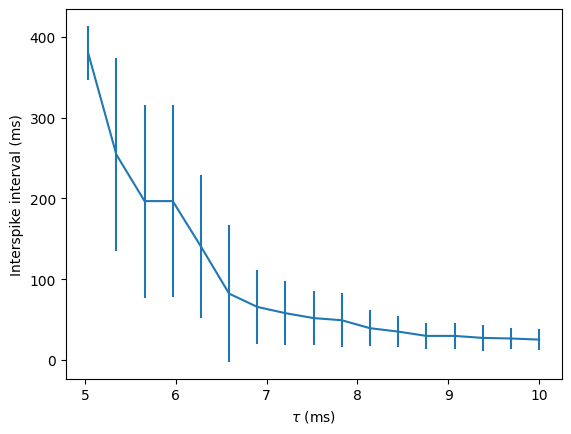

In [75]:
trains = spike_monitor.spike_trains()
isi_mu = np.full(num_tau, nan)  * second
isi_std = np.full(num_tau, nan) * second

for idx in range(num_tau):
    train = np.diff(trains[idx])
    if len(train) > 1:
        isi_mu[idx] = np.mean(train)
        isi_std[idx] = np.std(train)

plt.errorbar(tau_range/ms, isi_mu/ms, yerr=isi_std/ms)
plt.xlabel(r"$\tau$ (ms)")
plt.ylabel("Interspike interval (ms)");

In [76]:
start_scope()

In [77]:
area = 20000 * umetre ** 2
Cm = 1 * ufarad*cm**-2 * area
gl = 5e-5 * siemens * cm ** -2 * area
El = -65 * mV
EK = -90 * mV
ENa = 50 * mV
g_na = 100 * msiemens * cm ** -2 * area
g_kd = 30 * msiemens * cm ** -2 * area
VT = -63 * mV

In [78]:
start_scope()

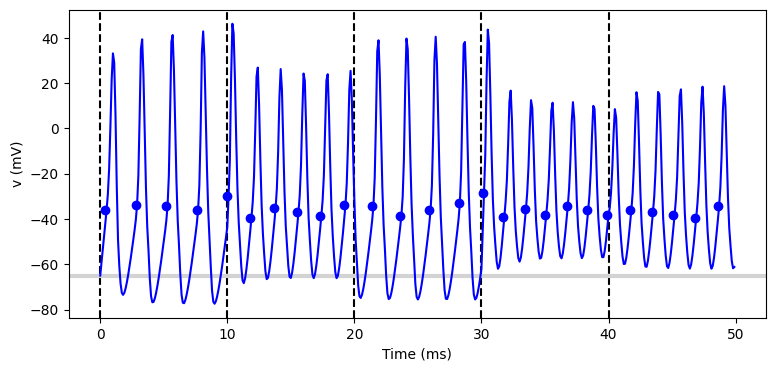

In [79]:
group = NeuronGroup(1, eqs_HH, threshold="v > -40 * mV", refractory="v > -40 * mV", method="exponential_euler")
group.v = El
state_monitor = StateMonitor(group, "v", record=True)
spike_monitor = SpikeMonitor(group, variables="v")
group.run_regularly("I = rand() * 50 * nA", dt=10*ms) # Runs every 10 ms as specified in the argument dt
run(50 * ms)
plt.figure(figsize=(9, 4))

for l in range(5):
    plt.axvline(l * 10, ls="--", c="k")

plt.axhline(El/mV, ls="-", c="lightgray", lw=3)
plt.plot(state_monitor.t/ms, state_monitor.v[0]/mV, "-b")
plt.plot(spike_monitor.t/ms, spike_monitor.v/mV, "ob")
plt.xlabel("Time (ms)")
plt.ylabel("v (mV)");

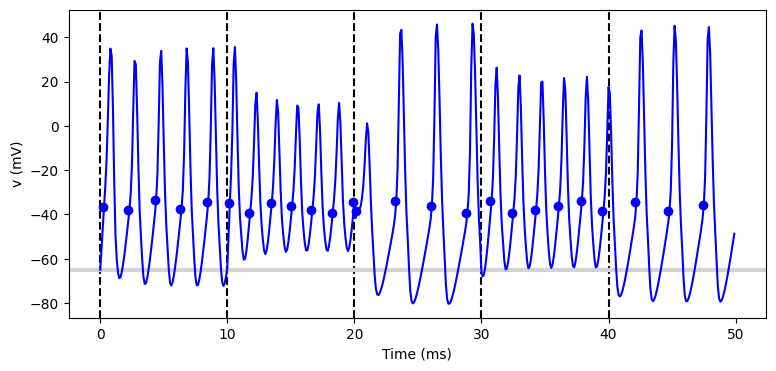

In [80]:
group = NeuronGroup(1, eqs_HH, threshold="v > -40 * mV", refractory="v > -40 * mV", method="exponential_euler")
group.v = El
state_monitor = StateMonitor(group, "v", record=True)
spike_monitor = SpikeMonitor(group, variables="v")

@network_operation(dt=10*ms) # Network operation for running additional code, such as the change_I function.
def change_I():
    group.I = rand()*50*nA

run(50 * ms)
plt.figure(figsize=(9, 4))

for l in range(5):
    plt.axvline(l * 10, ls="--", c="k")

plt.axhline(El/mV, ls="-", c="lightgray", lw=3)
plt.plot(state_monitor.t/ms, state_monitor.v[0]/mV, "-b")
plt.plot(spike_monitor.t/ms, spike_monitor.v/mV, "ob")
plt.xlabel("Time (ms)")
plt.ylabel("v (mV)");

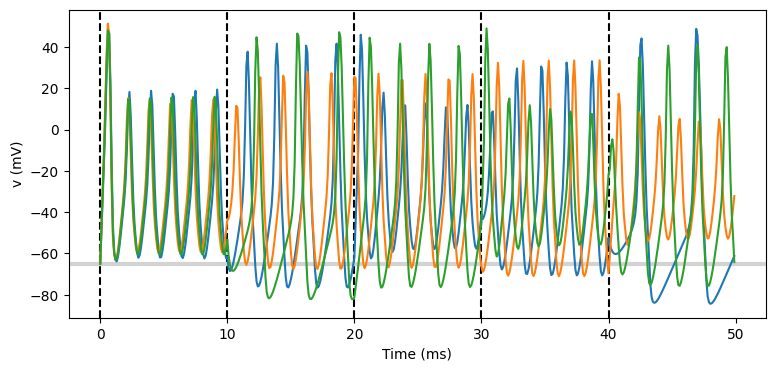

In [81]:
start_scope()

n = 3

eqs_HH_2 = """
dv/dt = (gl*(El-v) - g_na*(m*m*m)*h*(v-ENa) - g_kd*(n*n*n*n)*(v-EK) + I)/Cm : volt
dm/dt = 0.32*(mV**-1)*(13.*mV-v+VT)/
    (exp((13.*mV-v+VT)/(4.*mV))-1.)/ms*(1-m)-0.28*(mV**-1)*(v-VT-40.*mV)/
    (exp((v-VT-40.*mV)/(5.*mV))-1.)/ms*m : 1
dn/dt = 0.032*(mV**-1)*(15.*mV-v+VT)/
    (exp((15.*mV-v+VT)/(5.*mV))-1.)/ms*(1.-n)-.5*exp((10.*mV-v+VT)/(40.*mV))/ms*n : 1
dh/dt = 0.128*exp((17.*mV-v+VT)/(18.*mV))/ms*(1.-h)-4./(1+exp((40.*mV-v+VT)/(5.*mV)))/ms*h : 1
I : amp
C: farad
"""

group = NeuronGroup(n, eqs_HH_2, threshold="v > -40 * mV", refractory="v > -40 * mV", method="exponential_euler")
group.v = El
group.C = np.array([0.8, 1, 1.2]) * ufarad * cm ** -2 * area
state_monitor = StateMonitor(group, variables=True, record=True)

group.run_regularly("I = rand() * 50 * nA", dt=10*ms)
run(50 * ms)

plt.figure(figsize=(9, 4))

for l in range(5):
    axvline(l * 10, ls="--", c="k")

plt.axhline(El/mV, ls="-", c="lightgray", lw=3)
plt.plot(state_monitor.t/ms, state_monitor.v.T/mV, "-")
plt.xlabel("Time (ms)")
plt.ylabel("v (mV)");

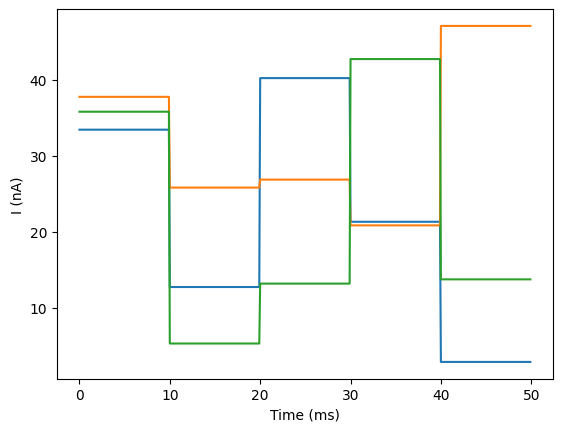

In [82]:
plt.plot(state_monitor.t/ms, state_monitor.I.T/nA, "-")
plt.xlabel("Time (ms)")
plt.ylabel("I (nA)");

In [97]:
start_scope()

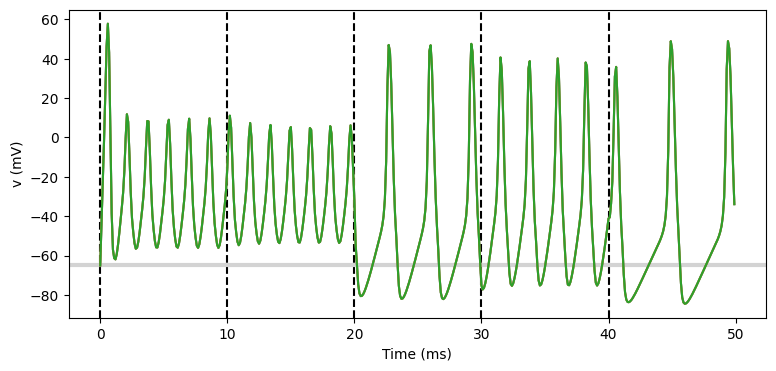

In [98]:
# Sharing current across the neuron group of n neurons

n = 3

eqs_HH_2 = """
dv/dt = (gl*(El-v) - g_na*(m*m*m)*h*(v-ENa) - g_kd*(n*n*n*n)*(v-EK) + I)/Cm : volt
dm/dt = 0.32*(mV**-1)*(13.*mV-v+VT)/
    (exp((13.*mV-v+VT)/(4.*mV))-1.)/ms*(1-m)-0.28*(mV**-1)*(v-VT-40.*mV)/
    (exp((v-VT-40.*mV)/(5.*mV))-1.)/ms*m : 1
dn/dt = 0.032*(mV**-1)*(15.*mV-v+VT)/
    (exp((15.*mV-v+VT)/(5.*mV))-1.)/ms*(1.-n)-.5*exp((10.*mV-v+VT)/(40.*mV))/ms*n : 1
dh/dt = 0.128*exp((17.*mV-v+VT)/(18.*mV))/ms*(1.-h)-4./(1+exp((40.*mV-v+VT)/(5.*mV)))/ms*h : 1
I : amp (shared)
C: farad
"""

group = NeuronGroup(n, eqs_HH_2, threshold="v > -40 * mV", refractory="v > -40 * mV", method="exponential_euler")
group.v = El
group.C = np.array([0.8, 1, 1.2]) * ufarad * cm ** -2 * area
state_monitor = StateMonitor(group, "v", record=True)

group.run_regularly("I = rand() * 50 * nA", dt=10*ms)
run(50 * ms)

plt.figure(figsize=(9, 4))

for l in range(5):
    axvline(l * 10, ls="--", c="k")

plt.axhline(El/mV, ls="-", c="lightgray", lw=3)
plt.plot(state_monitor.t/ms, state_monitor.v.T/mV, "-")
plt.xlabel("Time (ms)")
plt.ylabel("v (mV)");

In [117]:
start_scope()

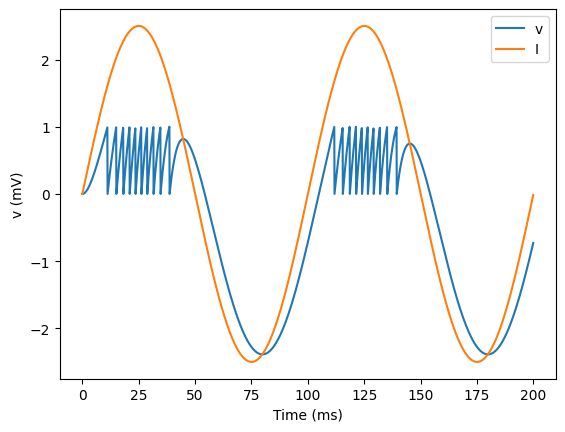

In [120]:
A = 2.5
f = 10 * Hz
tau = 5 * ms
eqs = """
dv/dt = (I-v)/tau : 1
I = A * sin(2*pi*f*t) : 1
"""

neuron_group = NeuronGroup(1, eqs, threshold="v>1", reset="v=0", method="euler")
state_monitor = StateMonitor(neuron_group, variables=True, record=True)
run(200*ms)

plt.plot(state_monitor.t/ms, state_monitor.v[0], label="v")
plt.plot(state_monitor.t/ms, state_monitor.I[0], label="I")
plt.xlabel("Time (ms)")
plt.ylabel("v (mV)")
plt.legend(loc="best");

In [103]:
start_scope()

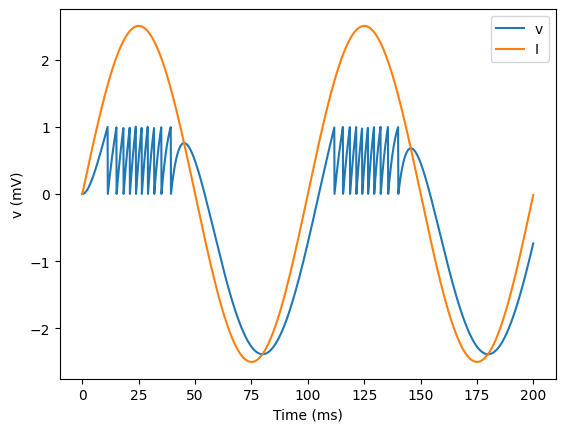

In [106]:
A = 2.5
f = 10 * Hz
tau = 5 * ms

t_recorded = np.arange(int(200*ms/defaultclock.dt)) * defaultclock.dt
I_recorded = TimedArray(A*sin(2*pi*f*t_recorded), dt=defaultclock.dt)

eqs = """
dv/dt = (I-v)/tau : 1
I = I_recorded(t) : 1
"""

neuron_group = NeuronGroup(1, eqs, threshold="v>1", reset="v=0", method="exact")
state_monitor = StateMonitor(neuron_group, variables=True, record=True)
run(200*ms)

plt.plot(state_monitor.t/ms, state_monitor.v[0], label="v")
plt.plot(state_monitor.t/ms, state_monitor.I[0], label="I")
plt.xlabel("Time (ms)")
plt.ylabel("v (mV)")
plt.legend(loc="best");

In [107]:
start_scope()

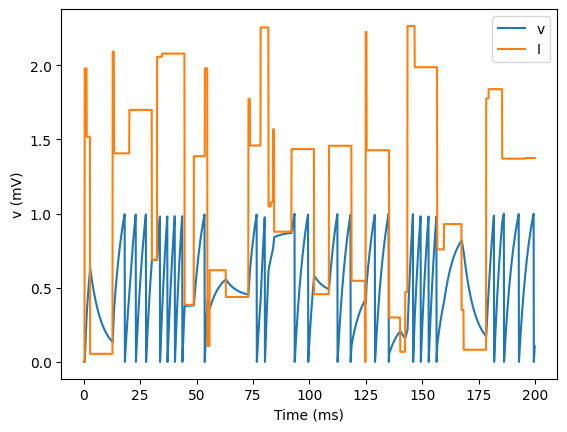

In [109]:
A = 2.5
f = 10 * Hz
tau = 5 * ms

num_samples = int(200*ms/defaultclock.dt)
I_arr = np.zeros(num_samples)

for _ in range(100):
    a = randint(num_samples)
    I_arr[a:a+100] = np.random.rand()

I_recorded = TimedArray(A*I_arr, dt=defaultclock.dt)

eqs = """
dv/dt = (I-v)/tau : 1
I = I_recorded(t) : 1
"""

neuron_group = NeuronGroup(1, eqs, threshold="v>1", reset="v=0", method="exact")
state_monitor = StateMonitor(neuron_group, variables=True, record=True)
run(200*ms)

plt.plot(state_monitor.t/ms, state_monitor.v[0], label="v")
plt.plot(state_monitor.t/ms, state_monitor.I[0], label="I")
plt.xlabel("Time (ms)")
plt.ylabel("v (mV)")
plt.legend(loc="best");